In [20]:
import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import time

### Downloading and Load Train FIles

In [21]:
import requests, hashlib, os

url       = "https://raw.githubusercontent.com/Jehuty4949/NSL_KDD/refs/heads/master/KDDTrain%2B.txt"
file_name = "KDDTrain+.txt"
file_hash = "1b86d2f957b33082081bba410fe129b475efebcc13c9014c3f447c8271aadf95"

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

if os.path.exists(file_name) and sha256_file(file_name) == file_hash:
    print("File already verified.")
else:
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(file_name, "wb") as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)
    assert sha256_file(file_name) == file_hash, "Hash mismatch!"
    print("Downloaded and verified.")

File already verified.


In [22]:
COLUMNS = [
    "duration", "protocol_type", "service", "flag",
    "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "logged_in", "num_compromised",
    "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count",
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

In [23]:
try:
    df = pd.read_csv("KDDTrain+.txt", header=None, names=COLUMNS)
except FileNotFoundError:
    raise SystemExit(
        "\n[ERROR] KDDTrain+.txt not found.\n"
        "Download it from: https://www.kaggle.com/datasets/hassan06/nslkdd\n"
        "Place KDDTrain+.txt in the same directory as this script.\n"
    )

print(f"Loaded {len(df):,} connections | {df['label'].nunique()} unique labels\n")

Loaded 125,973 connections | 23 unique labels



### Generalization

In [ ]:
ATTACK_MAP = {
    "normal": "normal",

# DoS
    "back": "DoS",
    "land": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "apache2": "DoS",
    "udpstorm": "DoS",
    "processtable": "DoS",
    "worm": "DoS",

# Probe
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "satan": "Probe",
    "mscan": "Probe",
    "saint": "Probe",

# R2L
    "ftp_write": "R2L",
    "guess_passwd": "R2L",
    "imap": "R2L",
    "multihop": "R2L",
    "phf": "R2L",
    "spy": "R2L",
    "warezclient": "R2L",
    "warezmaster": "R2L",
    "sendmail": "R2L",
    "named": "R2L",
    "snmpattack": "R2L",
    "snmpgetattack": "R2L",
    "httptunnel": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",

# U2R
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "perl": "U2R",
    "rootkit": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R",
    "ps": "U2R",
}
df["attack_family"] = df["label"].map(ATTACK_MAP).fillna("other")

print("Attack family distribution:")
print(df["attack_family"].value_counts().to_string())
print()

Attack family distribution:
attack_family
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52



### Discretization

In [ ]:
def bin_col(series, col_name, bins, labels):
    return pd.cut(series, bins=bins, labels=[f"{col_name}={l}" for l in labels],
                  include_lowest=True)

df["dur_bin"] = bin_col(df["duration"], "duration",
    [-1, 0, 10, 100, np.inf],
    ["zero", "low", "med", "high"])
df["src_bin"] = bin_col(df["src_bytes"], "src_bytes",
    [-1, 0, 1000, 50000, np.inf],
    ["zero", "small", "medium", "large"])
df["dst_bin"] = bin_col(df["dst_bytes"], "dst_bytes",
    [-1, 0, 1000, 50000, np.inf],
    ["zero", "small", "medium", "large"])
df["count_bin"] = bin_col(df["count"], "count",
    [-1, 1, 50, 200, np.inf],
    ["one", "few", "many", "flood"])
df["serror_bin"] = bin_col(df["serror_rate"], "serror_rate",
    [-0.01, 0, 0.5, 1.01],
    ["none", "some", "high"])
df["same_srv_bin"] = bin_col(df["same_srv_rate"], "same_srv_rate",
    [-0.01, 0.33, 0.66, 1.01],
    ["low", "med", "high"])

In [26]:
CATEGORICAL = ["protocol_type", "service", "flag", "attack_family"]
BINNED      = ["dur_bin", "src_bin", "dst_bin",
               "count_bin", "serror_bin", "same_srv_bin"]
BINARY      = ["logged_in", "land", "root_shell",
               "is_host_login", "is_guest_login"]

for col in BINARY:
    df[col] = df[col].apply(lambda v: f"{col}=yes" if v == 1 else None)

### Creating Da Basket

In [27]:
item_cols = CATEGORICAL + BINNED + BINARY

def row_to_basket(row):
    items = []
    for col in item_cols:
        v = row[col]
        if v is None or (isinstance(v, float) and np.isnan(v)):
            continue
        if col in CATEGORICAL:
            items.append(f"{col}={v}")
        else:
            items.append(str(v))
    return items

print("Building transaction baskets ...")
transactions = df.apply(row_to_basket, axis=1).tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)
print(f"Basket matrix: {basket_df.shape[0]:,} rows × {basket_df.shape[1]} items\n")

Building transaction baskets ...
Basket matrix: 125,973 rows × 116 items



### Running the Apriory itself

In [28]:
MIN_SUPPORT    = 0.05   # item/itemset must appear in ≥5% of connections
MIN_CONFIDENCE = 0.70   # rule must hold 70% of the time
MIN_LIFT       = 1.5    # rule must be 1.5× better than random

print(f"Running Apriori  (min_support={MIN_SUPPORT}) ...")
start_time = time.perf_counter()
frequent_itemsets = apriori(basket_df, min_support=MIN_SUPPORT, use_colnames=True, low_memory=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets = frequent_itemsets.sort_values(["length", "support"],ascending=[True, False])
end_time = time.perf_counter()
elapsed = end_time - start_time
print(f"Apriory Train completed in {elapsed:.2f} seconds")

print(f"Found {len(frequent_itemsets):,} frequent itemsets\n")

Running Apriori  (min_support=0.05) ...
Apriory Train completed in 32.85 seconds
Found 5,660 frequent itemsets



### Pruning

In [29]:
print(f"Mining association rules  (confidence≥{MIN_CONFIDENCE}, lift≥{MIN_LIFT}) ...")
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE
)
rules = rules[rules["lift"] >= MIN_LIFT].sort_values(
    ["confidence", "lift"], ascending=False
)
print(f"Found {len(rules):,} strong rules\n")

Mining association rules  (confidence≥0.7, lift≥1.5) ...
Found 176,846 strong rules



        itemsets_str  support  length
       duration=zero 0.920475       1
   protocol_type=tcp 0.815167       1
    serror_rate=none 0.689267       1
  same_srv_rate=high 0.622951       1
             flag=SF 0.594929       1
      dst_bytes=zero 0.539536       1
attack_family=normal 0.534583       1
     src_bytes=small 0.517674       1
       logged_in=yes 0.395736       1
      src_bytes=zero 0.392084       1


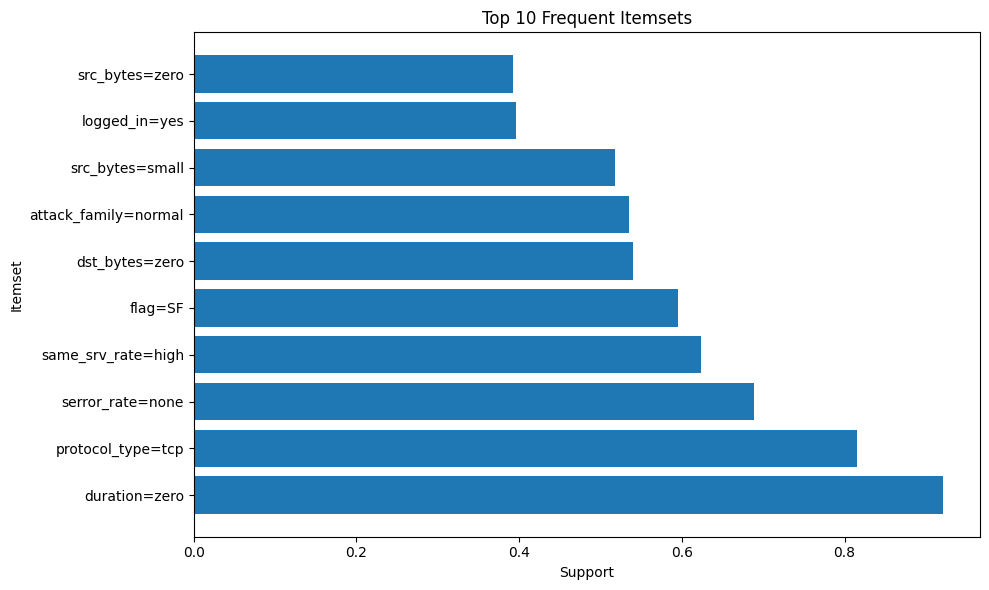

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def fmt_itemset(fs):
    return ", ".join(sorted(fs))

top_itemsets = frequent_itemsets.head(10).copy()

top_itemsets["itemsets_str"] = top_itemsets["itemsets"].apply(fmt_itemset)

display_df = top_itemsets[
    ["itemsets_str", "support", "length"]
]

print(display_df.to_string(index=False))

plt.figure(figsize=(10, 6))

plt.barh(
    top_itemsets["itemsets_str"],
    top_itemsets["support"]
)

plt.xlabel("Support")
plt.ylabel("Itemset")
plt.title("Top 10 Frequent Itemsets")

plt.tight_layout()
plt.show()

In [46]:
print("Attack Signature Rules:")

attack_labels = {f"attack_family={a}" for a in ["DoS","Probe","R2L","U2R"]}

attack_rules = rules[
    rules["consequents"].apply(lambda c: bool(c & attack_labels))
].copy()

if attack_rules.empty:
    print("  No attack-family rules found at current thresholds.")
    print("  Try lowering MIN_CONFIDENCE or MIN_LIFT.")
else:
    for _, row in attack_rules.head(15).iterrows():
        ant = fmt_itemset(row["antecedents"])
        con = fmt_itemset(row["consequents"])
        print(f"    antecedents: {ant}")
        print(f"    consequents: {con}")
        print(f"    support={row['support']:.3f}  "
              f"confidence={row['confidence']:.3f}  "
              f"lift={row['lift']:.2f}")
        print()
        

Attack Signature Rules:
    antecedents: {count=many, duration=zero, serror_rate=high, service=private}
    consequents: {attack_family=DoS, dst_bytes=zero}
    support=0.059  confidence=1.000  lift=2.80

    antecedents: {count=many, duration=zero, serror_rate=high, service=private}
    consequents: {attack_family=DoS}
    support=0.059  confidence=1.000  lift=2.74

    antecedents: {count=many, dst_bytes=zero, duration=zero, serror_rate=high, service=private}
    consequents: {attack_family=DoS}
    support=0.059  confidence=1.000  lift=2.74

    antecedents: {count=many, duration=zero, same_srv_rate=low, serror_rate=high, service=private}
    consequents: {attack_family=DoS, dst_bytes=zero}
    support=0.058  confidence=1.000  lift=2.80

    antecedents: {count=many, duration=zero, same_srv_rate=low, serror_rate=high, service=private}
    consequents: {attack_family=DoS}
    support=0.058  confidence=1.000  lift=2.74

    antecedents: {count=many, dst_bytes=zero, duration=zero, same

Frequent Itemsets Size Breakdown
  Size 1: 30 itemsets
  Size 2: 189 itemsets
  Size 3: 571 itemsets
  Size 4: 1,055 itemsets
  Size 5: 1,335 itemsets
  Size 6: 1,204 itemsets
  Size 7: 780 itemsets
  Size 8: 359 itemsets
  Size 9: 113 itemsets
  Size 10: 22 itemsets
  Size 11: 2 itemsets


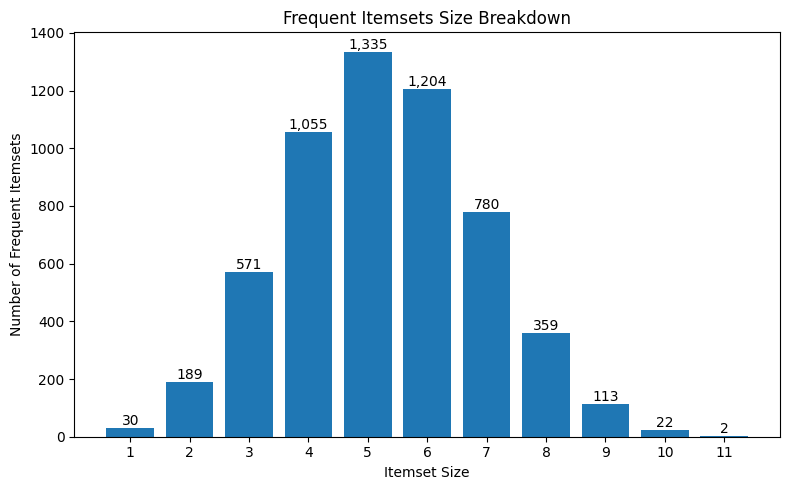

In [ ]:
import matplotlib.pyplot as plt

print("Frequent Itemsets Size Breakdown")

size_counts = frequent_itemsets["length"].value_counts().sort_index()

for size, count in size_counts.items():
    print(f"  Size {size}: {count:,} itemsets")

plt.figure(figsize=(8, 5))

plt.bar(size_counts.index.astype(str), size_counts.values)

plt.title("Frequent Itemsets Size Breakdown")
plt.xlabel("Itemset Size")
plt.ylabel("Number of Frequent Itemsets")

# show values on top of bars
for i, v in enumerate(size_counts.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [33]:
print()
print("TOP 10 Signature per Attack Family")

attack_families = ["DoS", "Probe", "R2L", "U2R"]

for family in attack_families:
    family_item = f"attack_family={family}"
    
    family_rules = rules[
        rules["consequents"].apply(lambda c: c == frozenset([family_item]))
    ].sort_values(["confidence", "lift"], ascending=False).head(10)
    
    print(f"  {family} Attack Signature")
    
    if family_rules.empty:
        print(f"  No pure signatures found (too rare — lower MIN_SUPPORT)")
    else:
        for i, (_, row) in enumerate(family_rules.iterrows(), 1):
            ant = sorted(row["antecedents"])
            print(f"\n  #{i}  confidence={row['confidence']:.3f}  "
                  f"lift={row['lift']:.2f}  support={row['support']:.3f}")
            for item in ant:
                print(f"       • {item}")
            print(f"       => attack_family={family}")


TOP 10 Signature per Attack Family
  DoS Attack Signature

  #1  confidence=1.000  lift=2.74  support=0.059
       • count=many
       • duration=zero
       • serror_rate=high
       • service=private
       => attack_family=DoS

  #2  confidence=1.000  lift=2.74  support=0.059
       • count=many
       • dst_bytes=zero
       • duration=zero
       • serror_rate=high
       • service=private
       => attack_family=DoS

  #3  confidence=1.000  lift=2.74  support=0.058
       • count=many
       • duration=zero
       • same_srv_rate=low
       • serror_rate=high
       • service=private
       => attack_family=DoS

  #4  confidence=1.000  lift=2.74  support=0.058
       • count=many
       • dst_bytes=zero
       • duration=zero
       • same_srv_rate=low
       • serror_rate=high
       • service=private
       => attack_family=DoS

  #5  confidence=1.000  lift=2.74  support=0.058
       • count=many
       • flag=S0
       • serror_rate=high
       • service=private
       => att

In [34]:
import requests, hashlib, os

url       = "https://raw.githubusercontent.com/Jehuty4949/NSL_KDD/refs/heads/master/KDDTrain%2B.txt"
file_name = "KDDTest+.txt"
file_hash = "fa46b0935342616aa83b7c2578db355b6a7aaabbc492248172c7a1e8b7ab8f84"

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

if os.path.exists(file_name) and sha256_file(file_name) == file_hash:
    print("File already verified.")
else:
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(file_name, "wb") as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)
    assert sha256_file(file_name) == file_hash, "Hash mismatch!"
    print("Downloaded and verified.")

File already verified.


In [35]:
try:
    test_df = pd.read_csv("KDDTest+.txt", header=None, names=COLUMNS)
except FileNotFoundError:
    raise SystemExit("[ERROR] KDDTest+.txt not found.")

test_df["attack_family"] = test_df["label"].map(ATTACK_MAP).fillna("normal")

In [36]:
test_df["dur_bin"]      = bin_col(test_df["duration"],     "duration",    [-1,0,10,100,np.inf],  ["zero","low","med","high"])
test_df["src_bin"]      = bin_col(test_df["src_bytes"],    "src_bytes",   [-1,0,1000,50000,np.inf], ["zero","small","medium","large"])
test_df["dst_bin"]      = bin_col(test_df["dst_bytes"],    "dst_bytes",   [-1,0,1000,50000,np.inf], ["zero","small","medium","large"])
test_df["count_bin"]    = bin_col(test_df["count"],        "count",       [-1,1,50,200,np.inf],  ["one","few","many","flood"])
test_df["serror_bin"]   = bin_col(test_df["serror_rate"],  "serror_rate", [-0.01,0,0.5,1.01],    ["none","some","high"])
test_df["same_srv_bin"] = bin_col(test_df["same_srv_rate"],"same_srv_rate",[-0.01,0.33,0.66,1.01],["low","med","high"])
for col in BINARY:
    test_df[col] = test_df[col].apply(lambda v: f"{col}=yes" if v == 1 else None)

test_transactions = test_df.apply(row_to_basket, axis=1).tolist()

In [37]:
test_array = te.transform(test_transactions)
test_basket = pd.DataFrame(test_array, columns=te.columns_)

In [38]:
attack_families = ["DoS", "Probe", "R2L", "U2R"]
sig_rules = {}
for family in attack_families:
    family_item = f"attack_family={family}"
    family_rules = rules[
        rules["consequents"].apply(lambda c: c == frozenset([family_item]))
    ].sort_values("confidence", ascending=False)
    sig_rules[family] = family_rules

def predict(basket_row):
    active_items = frozenset(
        col for col, val in zip(te.columns_, basket_row) if val
    )
    for family in attack_families:
        for _, rule in sig_rules[family].iterrows():
            if rule["antecedents"].issubset(active_items):
                return family
    return "normal"

print("Running predictions (this may take a minute)...")
start_time = time.perf_counter()
test_df["predicted"] = [predict(row) for row in test_basket.values]
end_time = time.perf_counter()
elapsed = end_time - start_time
print(f"FP-Growth Test completed in {elapsed:.2f} seconds")

Running predictions (this may take a minute)...
FP-Growth Test completed in 364.74 seconds


<Figure size 1000x500 with 0 Axes>

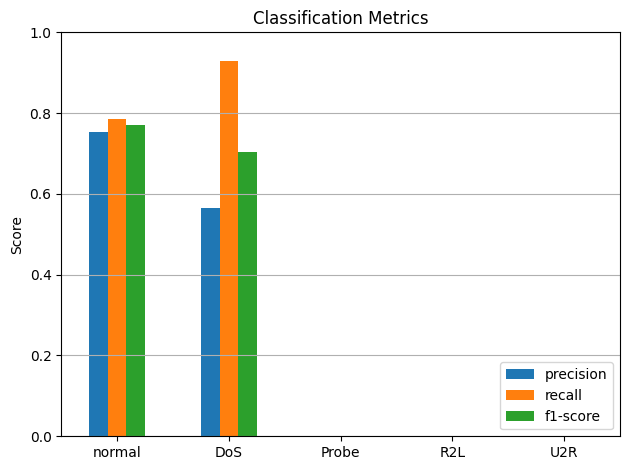

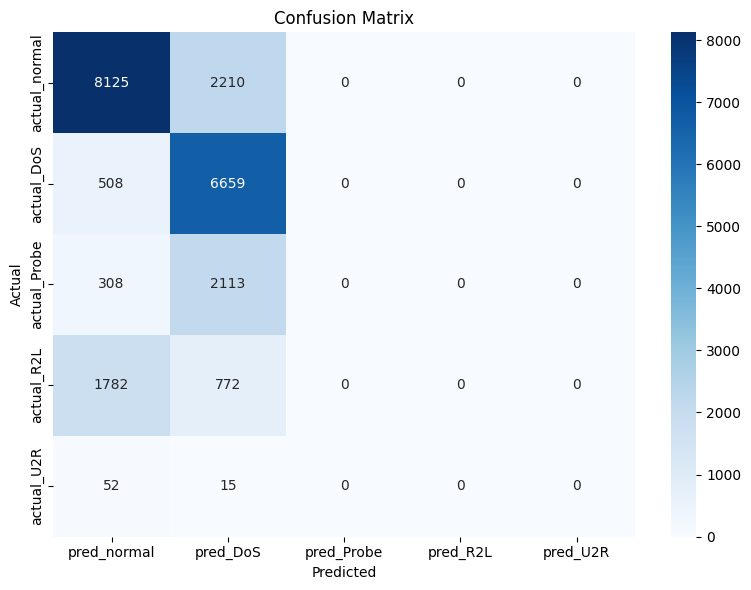

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

labels = ["normal", "DoS", "Probe", "R2L", "U2R"]

# Classification report
report = classification_report(
    test_df["attack_family"],
    test_df["predicted"],
    labels=labels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

# Confusion matrix
cm = confusion_matrix(
    test_df["attack_family"],
    test_df["predicted"],
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"actual_{x}" for x in labels],
    columns=[f"pred_{x}" for x in labels]
)

metrics_df = report_df.loc[labels, ["precision", "recall", "f1-score"]]

plt.figure(figsize=(10, 5))
metrics_df.plot(kind="bar")
plt.title("Classification Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()